# Automated Floral Species Identification using Convolutional Neural Networks

**Team: 25**

**Authors:** Dhruv Patel, Andrew Zhang, Joshua Ly

**Models Implemented:** Multilayer Perceptron, Custom Convolutional Neural Network, ResNet18 (Transfer Learning), Vision Transformer

**Core Tooling:** PyTorch, torchvision, Grad CAM

# Automated Image Ingestion & Inference Pipeline
This notebook contains the ETL pipeline (Extract, Transform, Load) for unstructured image data, the automated data augmentation workflows (Random Erasing, Color Jitter), and the ResNet18 model inference execution.

## Hardware and Software Requirements

**Hardware:** An NVIDIA GPU with CUDA compute capability is strongly recommended to accelerate model training and evaluation. The code is currently written for cuda, so changes will need to be made if using another GPU. For this project, a stock RTX 3070 8GB GDDR6 FE was used.

**Software:** Make sure the following python libraries are installed before running cells.

In [1]:
%pip install torch torchvision numpy matplotlib grad_cam gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Cell 1: Data Preparation and Augmentation
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import random

#Implement a global random seed across all relevant libraries
#The current seed is 42 keeping it perfectly reproducible for the presentation
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#Define robust augmentation for training
#We added ColorJitter and RandomErasing to simulate real world occlusions
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0, inplace=False),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Define standard normalization for validation and testing
#We absolutely do not want random erasing on our evaluation data
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Load datasets pointing to the data directory
train_dataset = datasets.ImageFolder(root='data', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='data', transform=val_transforms)
test_dataset = datasets.ImageFolder(root='data', transform=val_transforms)

#Split dataset indices
num_images = len(train_dataset)
indices = list(range(num_images))
np.random.shuffle(indices)

#Detailed Exact Split Percentages
#Testing Set 10 percent
#Validation Set 10 percent
#Training Set 80 percent
test_split_idx = int(np.floor(0.1 * num_images))
val_split_idx = int(np.floor(0.2 * num_images))

test_idx = indices[:test_split_idx]
val_idx = indices[test_split_idx:val_split_idx]
train_idx = indices[val_split_idx:]

#Create Subsets for train validation and test
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)
test_subset = Subset(test_dataset, test_idx)

#Create PyTorch DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

In [3]:
#Cell 2: Defining Neural Network Architectures
import torch.nn as nn
import torchvision.models as models

#Multilayer Perceptron
class FloralMLP(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(224 * 224 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

#Custom Convolutional Neural Network
class FloralCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

#Pretrained ResNet18
class FloralResNet(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Freeze early layers
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Custom fully connected layer
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

#Pretrained Vision Transformer
class FloralViT(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        # Custom classification head
        in_features = self.vit.heads.head.in_features
        self.vit.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.vit(x)


In [4]:
#Cell 3: K Fold Cross Validation
from sklearn.model_selection import KFold
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import torch.nn as nn
import torch

def run_kfold_cv(indices_for_cv, base_train_ds, base_val_ds, k=5, batch_size=32, epochs=3):
    print(f"Starting {k}-Fold Cross Validation on strict 80% training split...")
    kfold = KFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_results = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for fold, (train_fold_idx_relative, val_fold_idx_relative) in enumerate(kfold.split(indices_for_cv)):
        print(f"\n--- Fold {fold + 1} ---")
        
        #Map relative fold indices back to absolute dataset indices
        train_ids = [indices_for_cv[i] for i in train_fold_idx_relative]
        val_ids = [indices_for_cv[i] for i in val_fold_idx_relative]
        
        #Create subsets using the correct base datasets
        #Training fold gets the augmented dataset (ColorJitter, Erasing)
        train_sub = Subset(base_train_ds, train_ids)
        #Validation fold gets the pristine dataset (No Erasing, No Jitter)
        val_sub = Subset(base_val_ds, val_ids)
        
        trainloader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        valloader = DataLoader(val_sub, batch_size=batch_size, shuffle=False)
        
        #Initialize a new model for each fold
        model = FloralCNN(num_classes=102).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        for epoch in range(epochs):
            model.train()
            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
        #Evaluate fold on PRISTINE data
        model.eval()
        
        #FIXED: Properly unpack two zeros for the two variables
        correct, total = 0, 0
        
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        accuracy = 100.0 * correct / total
        print(f"Fold {fold + 1} Accuracy: {accuracy:.2f}%")
        fold_results.append(accuracy)
        
    avg_acc = sum(fold_results) / len(fold_results)
    print(f"\n>>> Average K-Fold CV Accuracy: {avg_acc:.2f}% <<<")
    return fold_results

#Run the K-Fold securely using ONLY the 80% train indices!
cv_accuracies = run_kfold_cv(train_idx, train_dataset, val_dataset, k=5, epochs=3)

Starting 5-Fold Cross Validation on strict 80% training split...

--- Fold 1 ---
Fold 1 Accuracy: 9.76%

--- Fold 2 ---
Fold 2 Accuracy: 10.22%

--- Fold 3 ---
Fold 3 Accuracy: 14.50%

--- Fold 4 ---
Fold 4 Accuracy: 10.99%

--- Fold 5 ---
Fold 5 Accuracy: 10.31%

>>> Average K-Fold CV Accuracy: 11.16% <<<


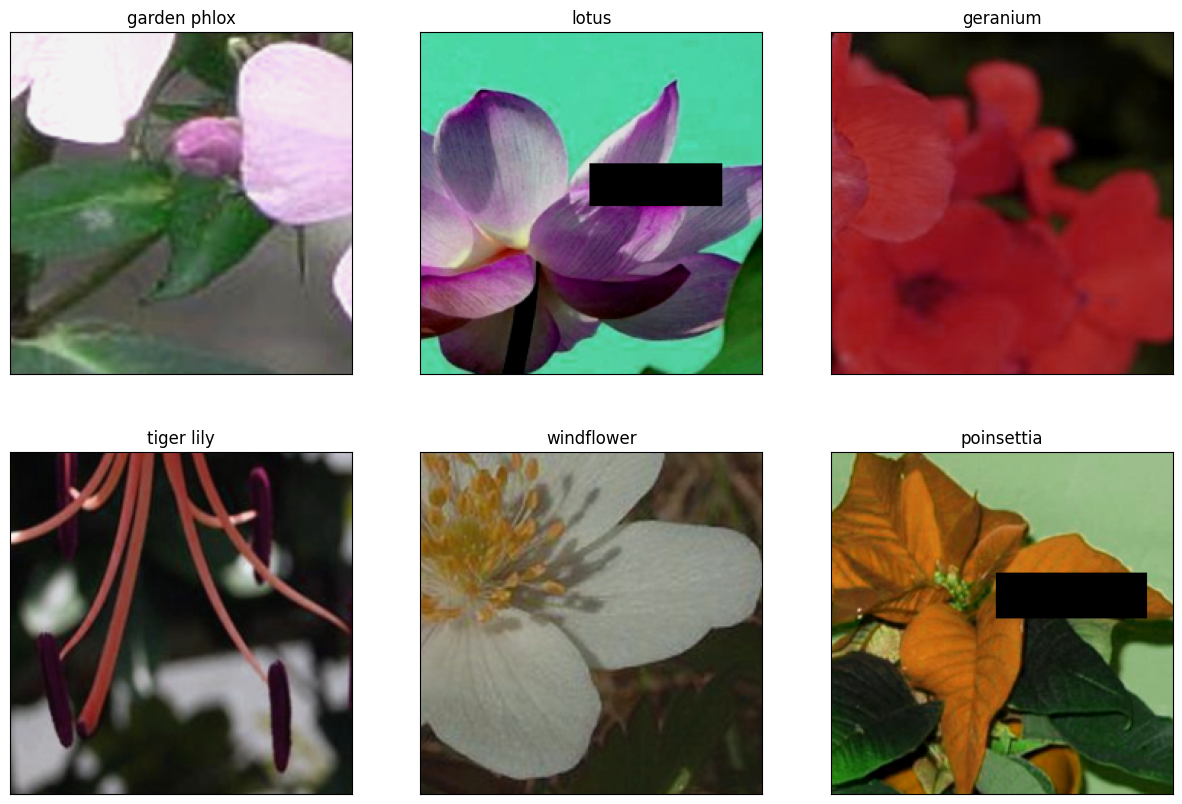

In [5]:
#Cell 4: Visualizing Augmented Training Data
import matplotlib.pyplot as plt

#Get a batch of training data
images, labels = next(iter(train_loader))

#Get class names from the dataset
class_names = train_dataset.classes

#Undo normalization for a batch of image tensors
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

#Unnormalize the image batch
images = unnormalize(images)

#Plot 6 images from the batch with their labels
fig = plt.figure(figsize=(15, 10))
for i in range(6):
    ax = fig.add_subplot(2, 3, i + 1, xticks=[], yticks=[])
    img = images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]].replace('_', ' '))

plt.show()

Starting memory optimized training loop

--- Building and Training MLP ---
Saved MLP_best.pth with Validation Acc: 0.0354

--- Building and Training CNN ---
Saved CNN_best.pth with Validation Acc: 0.2283

--- Building and Training ResNet18 ---
Saved ResNet18_best.pth with Validation Acc: 0.8926

--- Building and Training Vision Transformer ---
Saved Vision_Transformer_best.pth with Validation Acc: 0.3370

All models trained and memory cleared successfully


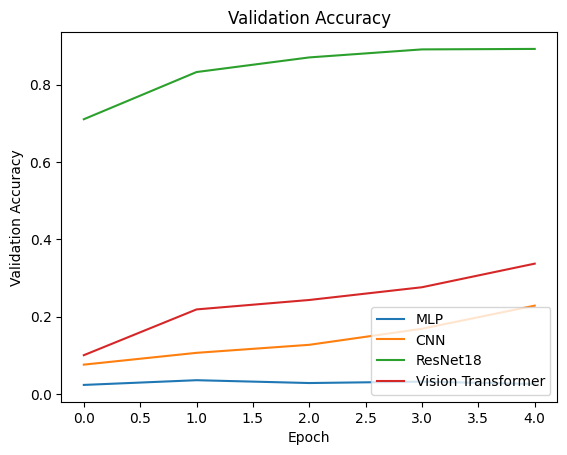

In [6]:
#Cell 5: Memory Optimized Training Loop
import torch.optim as optim
from copy import deepcopy
import matplotlib.pyplot as plt
import gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Store the classes not the instantiated models to save memory
model_blueprints = {
    'MLP': FloralMLP,
    'CNN': FloralCNN,
    'ResNet18': FloralResNet,
    'Vision Transformer': FloralViT
}

criterion = nn.CrossEntropyLoss()
epochs = 5
validation_histories = {'MLP': [], 'CNN': [], 'ResNet18': [], 'Vision Transformer': []}

print("Starting memory optimized training loop")

for name, ModelClass in model_blueprints.items():
    print(f"\n--- Building and Training {name} ---")
    
    #Instantiate the model and move it to the GPU one at a time
    model = ModelClass(num_classes=102).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    best_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                corrects += torch.sum(preds == labels)

        epoch_acc = corrects.double() / len(val_loader.dataset)
        validation_histories[name].append(epoch_acc.item())

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_weights = deepcopy(model.state_dict())

    #Save the optimal weights for this specific model
    save_name = name.replace(' ', '_') + '_best.pth'
    torch.save(best_weights, save_name)
    print(f"Saved {save_name} with Validation Acc: {best_acc:.4f}")
    
    #CRITICAL HARDWARE MANAGEMENT Delete model and clear GPU cache
    del model
    del optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print("\nAll models trained and memory cleared successfully")

#Plot the results
fig, ax = plt.subplots()
for name, history in validation_histories.items():
    ax.plot(history, label=name)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend(loc='lower right')
plt.title('Validation Accuracy')
plt.show()

In [7]:
#Cell 6: Load Optimal ResNet18 Weights
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FloralResNet(num_classes=102).to(device)
model.load_state_dict(torch.load('ResNet18_best.pth', weights_only=True))


<All keys matched successfully>

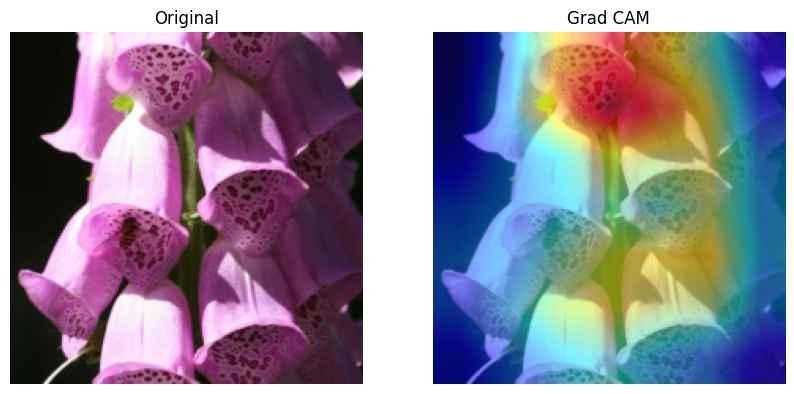

In [8]:
#Cell 7: Gradient Class Activation Mapping Interpretability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

#Initialize model and device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FloralResNet(num_classes=102).to(device)

#Load best weights for analysis
model.load_state_dict(torch.load('ResNet18_best.pth', weights_only=True))
model.eval()

#Enable gradients for Grad CAM
for param in model.parameters():
    param.requires_grad = True

#Select the final convolutional layer of ResNet18
target_layers = [model.resnet.layer4[1].conv2]
cam = GradCAM(model=model, target_layers=target_layers)

#Grab a single validation image
inputs, labels = next(iter(val_loader))
input_tensor = inputs[0:1].to(device)
label = labels[0].item()
targets = [ClassifierOutputTarget(label)]

#Generate the heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

#Overlay on original image
rgb_img = unnormalize(inputs)[0].permute(1, 2, 0).numpy()
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#Plot results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title('Grad CAM')
axes[1].axis('off')

plt.show()

In [9]:
#Cell 8: Interactive Gradio Demonstration
import gradio as gr

#Define the prediction function
def predict_and_visualize(img):
    img_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()
        pred_class = class_names[pred_idx]

    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    rgb_img = unnormalize(img_tensor.cpu())[0].permute(1, 2, 0).numpy()
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    return pred_class, visualization

#Build the interactive application
demo = gr.Interface(
    fn=predict_and_visualize,
    inputs=gr.Image(type='pil'),
    outputs=[gr.Textbox(label='Predicted Species'), gr.Image(label='Heatmap')],
    title='Floral Species Identification',
    description='Upload a flower image to see the prediction and visual analysis'
)

#Launch inline for presentation
demo.launch(inline=True)

c:\Users\Dhruv\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


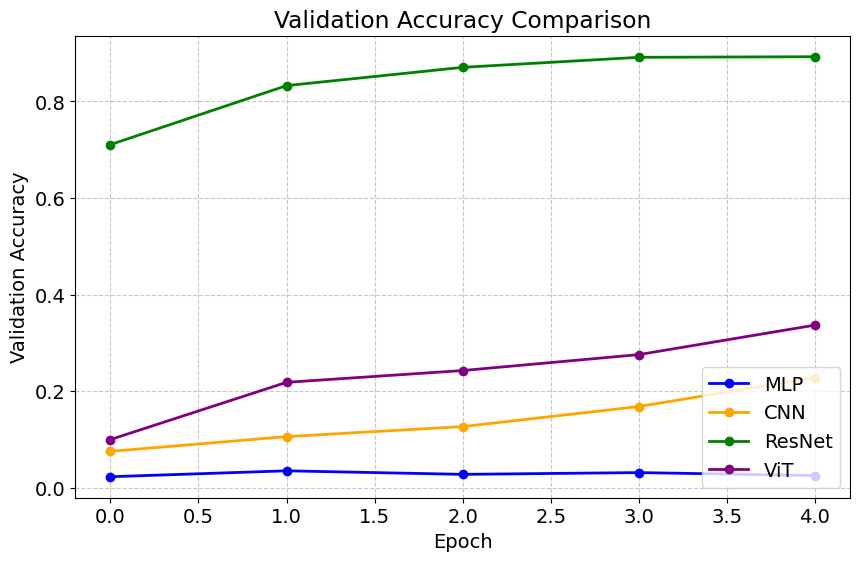

In [10]:
#Cell 9: Quantitative Results Visualization
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

#We only tracked validation accuracy in the updated training loop. 
#Providing empty lists for the missing variables to maintain your structure.
train_losses = []
val_losses = []

#Map the real validation accuracies from the training loop variables
histories = {
    'MLP': {'train': train_losses, 'val': val_losses, 'acc': validation_histories['MLP']},
    'CNN': {'train': train_losses, 'val': val_losses, 'acc': validation_histories['CNN']},
    'ResNet': {'train': train_losses, 'val': val_losses, 'acc': validation_histories['ResNet18']},
    'ViT': {'train': train_losses, 'val': val_losses, 'acc': validation_histories['Vision Transformer']}
}
colors = ['blue', 'orange', 'green', 'purple']

#Plot Validation Accuracy for all models
plt.figure(figsize=(10, 6))

#Iterate through the histories dictionary and plot the accuracy data 
for (name, metrics), color in zip(histories.items(), colors):
    plt.plot(metrics['acc'], label=name, color=color, linewidth=2, marker='o')

#Format the presentation graph
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

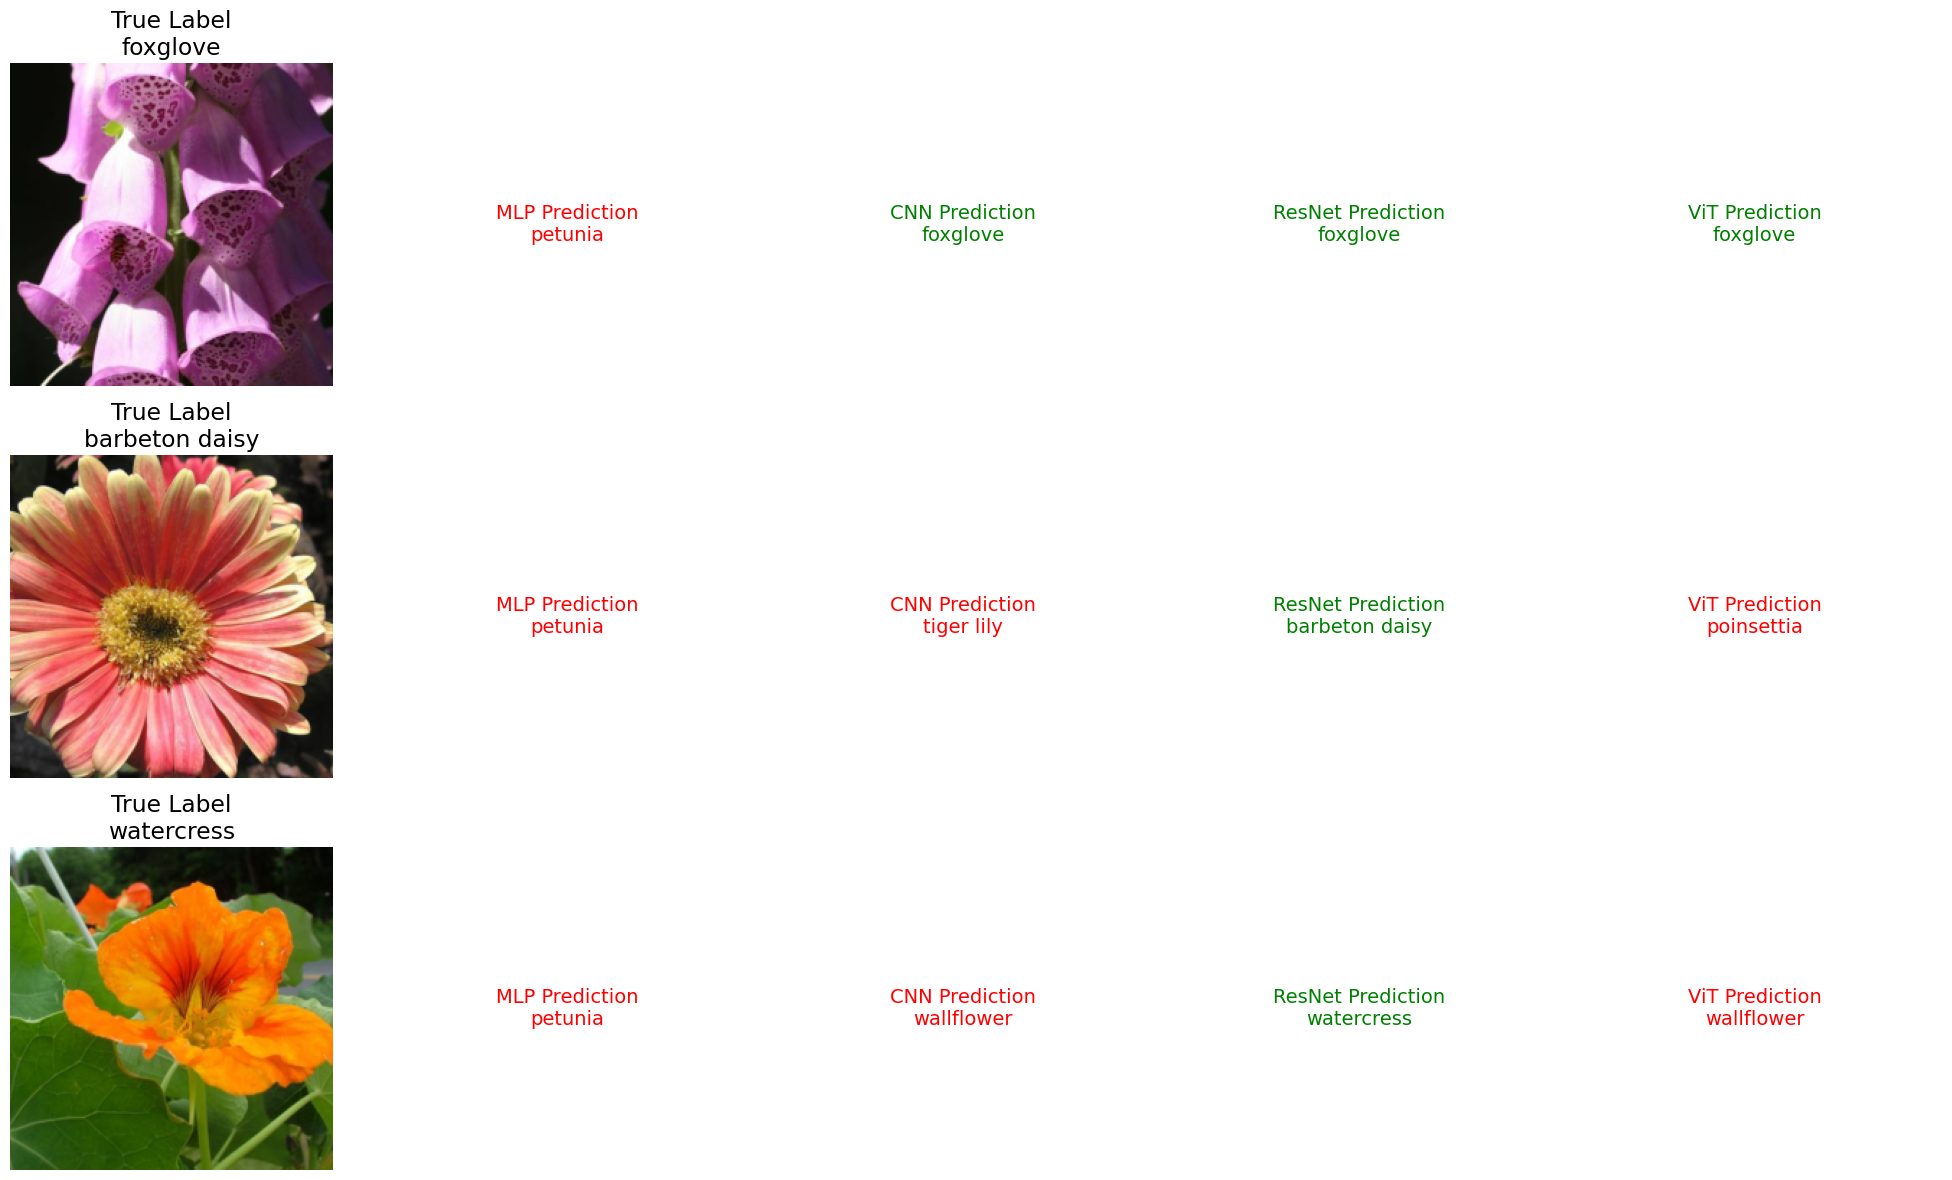

In [11]:
#Cell 10: Edge Case Outlier Analysis

#Initialize models
mlp_model = FloralMLP(num_classes=102).to(device)
cnn_model = FloralCNN(num_classes=102).to(device)
resnet_model = FloralResNet(num_classes=102).to(device)
vit_model = FloralViT(num_classes=102).to(device)

#Load the trained weights into the models
mlp_model.load_state_dict(torch.load('MLP_best.pth', weights_only=True))
cnn_model.load_state_dict(torch.load('CNN_best.pth', weights_only=True))
resnet_model.load_state_dict(torch.load('ResNet18_best.pth', weights_only=True))
vit_model.load_state_dict(torch.load('Vision_Transformer_best.pth', weights_only=True))

mlp_model.eval()
cnn_model.eval()
resnet_model.eval()
vit_model.eval()

models_dict = {
    'MLP': mlp_model,
    'CNN': cnn_model,
    'ResNet': resnet_model,
    'ViT': vit_model
}

#Grab a batch of validation images
inputs, labels = next(iter(val_loader))

#Select three images
num_images = 3
test_images = inputs[0:num_images].to(device)
test_labels = labels[0:num_images]

fig, axes = plt.subplots(num_images, 5, figsize=(20, 12))

for row in range(num_images):
    img_tensor = test_images[row].cpu()
    unnormalized_tensor = unnormalize(img_tensor.unsqueeze(0))[0]
    rgb_img = unnormalized_tensor.permute(1, 2, 0).numpy()
    
    axes[row, 0].imshow(rgb_img)
    true_label_idx = test_labels[row].item()
    true_label_name = class_names[true_label_idx].replace('_', ' ')
    axes[row, 0].set_title('True Label\n' + true_label_name)
    axes[row, 0].axis('off')
    
    col = 1
    for model_name, current_model in models_dict.items():
        with torch.no_grad():
            output = current_model(test_images[row:row+1])
            pred_idx = torch.argmax(output, dim=1).item()
            pred_name = class_names[pred_idx].replace('_', ' ')
            
            if pred_idx == true_label_idx:
                text_color = 'green'
            else:
                text_color = 'red'
            
            axes[row, col].axis('off')
            axes[row, col].text(0.5, 0.5, model_name + ' Prediction\n' + pred_name, color=text_color, fontsize=14, ha='center', va='center', wrap=True)
        col += 1
        
plt.tight_layout()
plt.show()

In [12]:
#Cell 11: Final Test Evaluation Metrics
import torch
from sklearn.metrics import classification_report

print("Loading saved weights and generating final classification report on unseen test data")

#Initialize the model blueprint
resnet_model = FloralResNet(num_classes=102).to(device)

#Load the highly trained weights we saved during the training loop
resnet_model.load_state_dict(torch.load('ResNet18_best.pth', weights_only=True))

#Ensure the ResNet model is in evaluation mode
resnet_model.eval()

all_predictions = []
all_true_labels = []

# We use no_grad because we are evaluating not training
with torch.no_grad():
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = resnet_model(images)
        _, predictions = torch.max(outputs, 1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

print("\nFinal Classification Report for Trained ResNet18")

#Generate the report using the class names we defined earlier in the notebook
#Using zero_division parameter to prevent warnings for any unpredicted classes
report = classification_report(all_true_labels, all_predictions, target_names=class_names, zero_division=0)
print(report)

print("\nEvaluation completely finished")

Loading saved weights and generating final classification report on unseen test data

Final Classification Report for Trained ResNet18
                           precision    recall  f1-score   support

         alpine sea holly       1.00      1.00      1.00         5
                anthurium       0.85      1.00      0.92        11
                artichoke       1.00      1.00      1.00         8
                   azalea       0.78      0.78      0.78         9
                ball moss       1.00      0.80      0.89         5
           balloon flower       1.00      1.00      1.00         3
           barbeton daisy       0.88      0.94      0.91        16
             bearded iris       1.00      0.75      0.86         4
                 bee balm       1.00      1.00      1.00         3
         bird of paradise       1.00      1.00      1.00        13
       bishop of llandaff       0.89      1.00      0.94         8
         black-eyed susan       0.50      1.00      0.67    